### Import libraries 📚

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 📌 General Information


### Load the dataset



In [ ]:
df = pd.read_csv("../dataset/student_data.csv")             # Load dataset

df.head()

### Perform Exploratory Data Analysis (EDA) 🔍


In [ ]:
print(f"Dataset shape: {df.shape}")                           # Shape

In [ ]:
print(f"Columns names: \n\n{df.columns.unique()}")            # Column names

In [ ]:
df.info()                                                     # Info

In [ ]:
numerical_columns = df.select_dtypes(include="number").columns

print(df[numerical_columns].describe())                       # Describe numerical columns

In [ ]:
print(f"Column data types: {df.dtypes}")                     # Columns types

In [ ]:
print(f"Missing values:\n{df.isnull().sum()}")                # Missing values

In [ ]:
print(f"Duplicated rows: {df.duplicated().sum()}")            # Duplicates

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns.unique())


In [ ]:
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

### 📈 Distribution


In [ ]:
print(f"Max Final Grade: {df.G3.max()}\n")                   # Max Final Grade
print(f"Min Final Grade: {df.G3.min()}\n")                   # Min Final Grade
print(f"Mean Final Grade: {df.G3.mean()}")                   # Mean Final Grade

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=12, edgecolor="black")
plt.title("Distribution of Student Ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of students")
plt.show()

In [ ]:

studytime_labels = {1: "<2 hours", 2: "2–5 hours", 3: "5–10 hours", 4: ">10 hours"}
studytime_counts = df["studytime"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(studytime_counts.index, studytime_counts.values, edgecolor="black")
plt.title("Weekly Study Time Distribution")
plt.xlabel("Weekly study time")
plt.ylabel("Number of students")
plt.xticks(studytime_counts.index, [studytime_labels[value] for value in studytime_counts.index])
plt.show()

In [ ]:
categorical_summary = pd.DataFrame({
    "Unique values": df[categorical_columns].nunique(),
    "Most common value": df[categorical_columns].mode().iloc[0],
    "Most common count": df[categorical_columns].apply(lambda column: column.value_counts().iloc[0])
})
categorical_summary

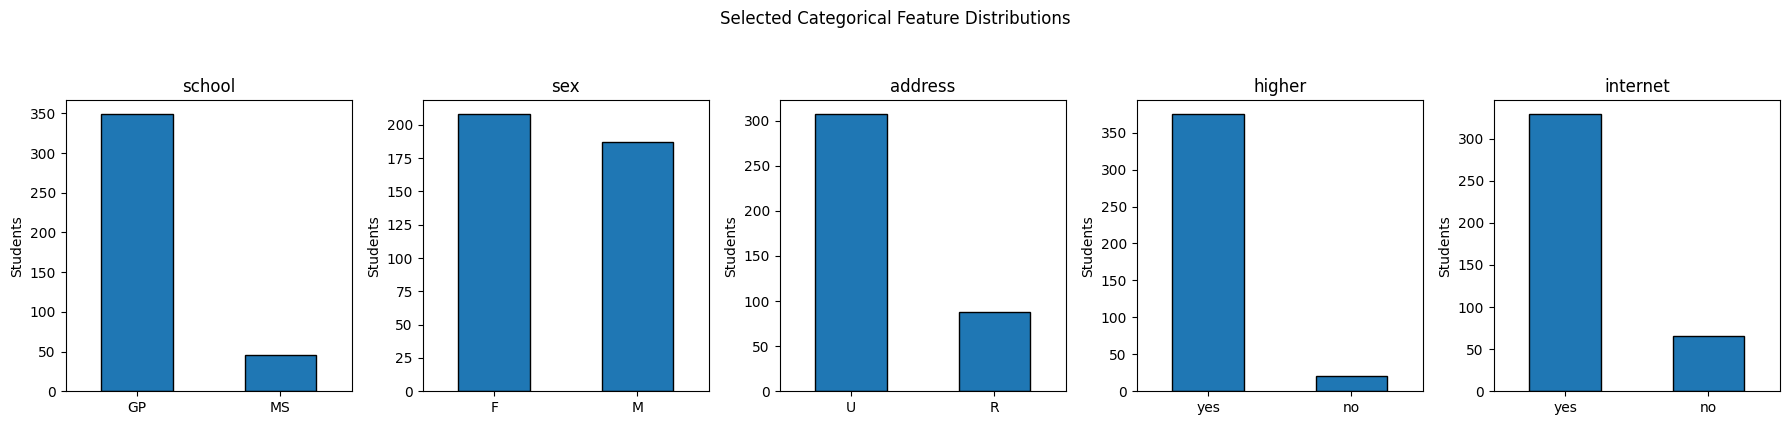

In [169]:
selected_categorical_columns = ["school", "sex", "address", "higher", "internet"]
fig, axes = plt.subplots(1, len(selected_categorical_columns), figsize=(18, 4))

for ax, col in zip(axes, selected_categorical_columns):
    df[col].value_counts().plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Students")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Selected Categorical Feature Distributions", y=1.05)
plt.tight_layout()
plt.show()

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


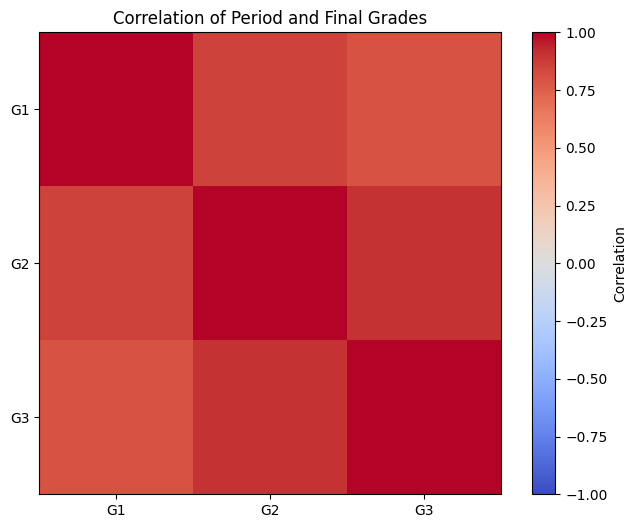

,mean,median,count
school,,,
GP,10.49,11.0,349
MS,9.85,10.0,46


,mean,median,count
sex,,,
F,9.97,10.0,208
M,10.91,11.0,187


,mean,median,count
address,,,
R,9.51,10.0,88
U,10.67,11.0,307


,mean,median,count
higher,,,
no,6.80,8.0,20
yes,10.61,11.0,375


,mean,median,count
internet,,,
no,9.41,10.0,66
yes,10.62,11.0,329


In [168]:
# Correlations between numerical features and the final grade

g3_correlations = df[numerical_columns].corr()["G3"].sort_values(ascending=False)
print(g3_correlations)

plt.figure(figsize=(8, 6))
plt.imshow(df[["G1", "G2", "G3"]].corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(3), ["G1", "G2", "G3"])
plt.yticks(range(3), ["G1", "G2", "G3"])
plt.title("Correlation of Period and Final Grades")
plt.show()

# Average final grade by selected categorical features
for col in ["school", "sex", "address", "higher", "internet"]:
    display(df.groupby(col)["G3"].agg(["mean", "median", "count"]).round(2))